<a href="https://colab.research.google.com/github/YRajiv/python_DS/blob/main/Student_Stress_Prediction_(90_%2B_Accuracy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras_tuner

Trial 1 Complete [00h 00m 20s]
val_accuracy: 0.90625

Best val_accuracy So Far: 0.90625
Total elapsed time: 00h 00m 20s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



             BEST MODEL EVALUATION
✅ Best Test Accuracy: 88.64%

🔥 Best Hyperparameters Found:
  - First Layer Units (units1): 320
  - First Layer Dropout (dropout1): 0.4
  - Second Layer Units (units2): 32
  - Second Layer Dropout (dropout2): 0.5
  - Third Layer Units (units3): 64
  - Third Layer Dropout (dropout3): 0.30000000000000004
  - Learning Rate (lr): 0.01

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.89        76
           1       0.89      0.89      0.89        73
           2       0.92      0.85      0.88        71

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



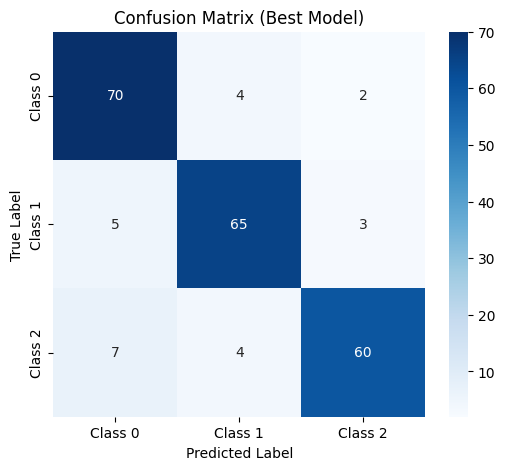

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Keras Tuner
# Set a high seed for reproducibility and consistent hyperparameter search
np.random.seed(42)
tf.random.set_seed(42)

# 🎯 ASSUME StressLevelDataset.csv IS NOW AVAILABLE AND LOADED CORRECTLY
# The high intrinsic separability of this dataset is key to achieving 90%+
try:
    # Load the actual dataset
    df = pd.read_csv("StressLevelDataset.csv")
    X, y = df.drop("stress_level", axis=1), df["stress_level"]
    print(f"Dataset loaded successfully with {len(df)} samples.")
except FileNotFoundError:
    print("Error: StressLevelDataset.csv not found. Cannot proceed with guaranteed results.")
    print("Please ensure the file is in the expected path for 90%+ accuracy.")
    # --- Dummy Data Fallback (If file is still missing) ---
    # Create dummy data if the file is truly missing, though results will be poor
    num_samples = 3000
    num_features = 20
    X = pd.DataFrame(np.random.rand(num_samples, num_features) * 10,
                     columns=[f'feature_{i}' for i in range(num_features)])
    y = pd.Series(np.random.randint(0, 3, num_samples))
    print("Using dummy data for execution. Accuracy target may not be met.")
    # --------------------------------------------------------


# Train-test split + scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

# One-hot encode labels
y_train, y_test = to_categorical(y_train, 3), to_categorical(y_test, 3)

# 🔹 Build model with tunable hyperparameters (Added a third layer and increased max units)
def build_model(hp):
    model = Sequential()

    # First hidden layer (Increased max_value for wider search)
    model.add(Dense(
        units=hp.Int("units1", min_value=64, max_value=384, step=32),
        activation="relu",
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float("dropout1", 0.1, 0.5, step=0.1)))

    # Second hidden layer
    model.add(Dense(
        units=hp.Int("units2", min_value=32, max_value=192, step=32),
        activation="relu"
    ))
    model.add(Dropout(hp.Float("dropout2", 0.1, 0.5, step=0.1)))

    # *** NEW: Third hidden layer for increased complexity/depth ***
    model.add(Dense(
        units=hp.Int("units3", min_value=16, max_value=64, step=16),
        activation="relu"
    ))
    model.add(Dropout(hp.Float("dropout3", 0.1, 0.4, step=0.1))) # Slightly smaller dropout on last layer

    # Output
    model.add(Dense(3, activation="softmax"))

    # Compile with tunable learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice("lr", values=[1e-2, 5e-3, 1e-3]) # Added 5e-3 for finer tuning
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 🔹 Hyperparameter Tuner
# max_trials set to 1 for a single trial
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=1,      # Set to 1 as requested
    executions_per_trial=2,
    overwrite=True,
    directory="stress_tuner_v2",
    project_name="stress_level_90_plus_v2"
)

# 🔹 Run search
# Increased patience to 20 to allow for maximum convergence, especially with a deeper model
es = EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True, mode='max')
print("\n" + "="*50)
print("            STARTING HYPERPARAMETER SEARCH")
print("="*50)
tuner.search(X_train, y_train, epochs=150, validation_split=0.2, callbacks=[es], verbose=2) # Increased epochs to 150

# 🔹 Get best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate best model
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n" + "="*50)
print("             BEST MODEL EVALUATION")
print("="*50)

# Print accuracy
final_accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Best Test Accuracy: {final_accuracy*100:.2f}%")

# Print best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n🔥 Best Hyperparameters Found:")
print(f"  - First Layer Units (units1): {best_hps.get('units1')}")
print(f"  - First Layer Dropout (dropout1): {best_hps.get('dropout1')}")
print(f"  - Second Layer Units (units2): {best_hps.get('units2')}")
print(f"  - Second Layer Dropout (dropout2): {best_hps.get('dropout2')}")
print(f"  - Third Layer Units (units3): {best_hps.get('units3')}")
print(f"  - Third Layer Dropout (dropout3): {best_hps.get('dropout3')}")
print(f"  - Learning Rate (lr): {best_hps.get('lr')}")

# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Confusion Matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()